## Debug Get Betas for Stim1&2 

- problem: TR different in Miguel (numrisk - 2.8) compared to Dyscalc (dnumrisk 2.3 )
--> messed up DM


works in noteboook, but `fit_glmDenoise_bothStim.py` via command line not ?!

In [16]:
from glmsingle.glmsingle import GLM_single
import argparse
import os
import os.path as op
from nilearn import image
from numrisk.utils.data import Subject
from nilearn.glm.first_level import make_first_level_design_matrix
import numpy as np
import pandas as pd
import warnings
import nibabel as nib
warnings.filterwarnings('ignore')

runs = range(1, 7)
N_runs = len(runs)
space = 'fsaverage5' #'T1w'

from fit_glmDenoise_bothStim import load_fmri_data
from fit_glmDenoise_bothStim import get_fmri_events_bothStim



In [17]:
#dataset ='numrisk' #'smile1'#
bids_folder = f'/mnt_AdaBD_largefiles/Data/SMILE_DATA/DNumRisk/ds-numrisk'
tr = 2.827

#bids_folder = '/mnt_03/ds-dnumrisk', tr=2.3

subject = 3

In [18]:
sub = f'{int(subject):02d}'
session = 1

key = f'glm_stim.denoise'
base_dir = op.join(bids_folder, 'derivatives', key, f'sub-{sub}', f'ses-{session}', 'func')
os.makedirs(base_dir, exist_ok=True)


In [19]:
onsets = get_fmri_events_bothStim(sub, session, runs, bids_folder)

im_data = load_fmri_data(sub, bids_folder=bids_folder, space=space) # _bold missing for numrisk
N_volumes = np.shape(im_data)[-1] # number of volumes
frametimes = np.linspace(tr/2., (N_volumes - .5)*tr, N_volumes)
onsets['onset'] = ((onsets['onset']+tr/2.) // 2.3) * 2.3

dm = [make_first_level_design_matrix(frametimes, onsets.loc[run].sort_values('onset'), hrf_model='fir', oversampling=100.,
                                        drift_order=0,
                                        drift_model=None).drop('constant', axis=1) for run in runs]

dm = pd.concat(dm, keys=runs, names=['run']).fillna(0) # keys = range(1, 7)
dm.columns = [c.replace('_delay_0', '') for c in dm.columns]
dm /= dm.max()
dm[dm < 1.0] = 0.0

print(dm.shape)

X = [dm.loc[run].values for run in runs]
np.mean(dm.sum(axis=0))

(1134, 432)


1.0

In [20]:
opt = dict()
opt['wantlibrary'] = 1 # set important fields for completeness (but these would be enabled by default)
opt['wantglmdenoise'] = 1
opt['wantfracridge'] = 1
opt['wantfileoutputs'] = [0, 0, 0, 1] # keep the relevant outputs in memory and also save them to the disk

glmsingle_obj = GLM_single(opt)
results_glmsingle = glmsingle_obj.fit(
    X,
    im_data,
    0.6,
    tr,
    outputdir=base_dir,
    figuredir = op.join(base_dir, 'GLMestimatesingletrialfigures') # would be written to cwd otherwise and could crash when multiple nodes use it a the same time 
    )

*** FITTING TYPE-A MODEL (ONOFF) ***

fitting model...
done.

preparing output...
done.

computing model fits...
done.

computing R^2...
done.

computing SNR...
done.

*** Setting brain R2 threshold to 0.14571408253858628 ***

*** FITTING TYPE-B MODEL (FITHRF) ***



chunks: 100%|██████████| 1/1 [01:07<00:00, 67.34s/it]


*** DETERMINING GLMDENOISE REGRESSORS ***

*** CROSS-VALIDATING DIFFERENT NUMBERS OF REGRESSORS ***



chunks: 100%|██████████| 1/1 [06:15<00:00, 375.72s/it]



*** FITTING TYPE-C MODEL (GLMDENOISE) ***



chunks: 100%|██████████| 1/1 [00:49<00:00, 49.93s/it]


*** FITTING TYPE-D MODEL (GLMDENOISE_RR) ***



chunks: 100%|██████████| 1/1 [13:48<00:00, 828.64s/it]



*** Saving results to /mnt_AdaBD_largefiles/Data/SMILE_DATA/DNumRisk/ds-numrisk/derivatives/glm_stim.denoise/sub-03/ses-1/func/TYPED_FITHRF_GLMDENOISE_RR.npy. ***

*** All model types done ***

*** return model types in results ***



In [21]:
import nibabel as nib
betas = results_glmsingle['typed']['betasmd']

n_vertices_total, n_betas = betas.shape[:2]
n_vertices_hemi = n_vertices_total // 2

hemi_data = {
    'L': betas[:n_vertices_hemi],
    'R': betas[n_vertices_hemi:]
}

for hemi, hemi_betas in hemi_data.items():
    # Split N1 / N2
    hemi_betas_n1 = hemi_betas[..., ::2]
    hemi_betas_n2 = hemi_betas[..., 1::2]

    # Save each as .func.gii
    for name, hemi_b in zip(['stims1', 'stims2'], [hemi_betas_n1, hemi_betas_n2]):
        darrays = [nib.gifti.GiftiDataArray(hemi_b[:, i].astype(np.float32)) for i in range(hemi_b.shape[1])]
        gii = nib.GiftiImage(darrays=darrays)
        fn = op.join(base_dir, f'sub-{sub}_ses-{session}_task-magjudge_space-{space}_desc-{name}_pe_hemi-{hemi}.gii')
        gii.to_filename(fn)
        print(f"Saved {fn}")

Saved /mnt_AdaBD_largefiles/Data/SMILE_DATA/DNumRisk/ds-numrisk/derivatives/glm_stim.denoise/sub-03/ses-1/func/sub-03_ses-1_task-magjudge_space-fsaverage5_desc-stims1_pe_hemi-L.gii
Saved /mnt_AdaBD_largefiles/Data/SMILE_DATA/DNumRisk/ds-numrisk/derivatives/glm_stim.denoise/sub-03/ses-1/func/sub-03_ses-1_task-magjudge_space-fsaverage5_desc-stims2_pe_hemi-L.gii
Saved /mnt_AdaBD_largefiles/Data/SMILE_DATA/DNumRisk/ds-numrisk/derivatives/glm_stim.denoise/sub-03/ses-1/func/sub-03_ses-1_task-magjudge_space-fsaverage5_desc-stims1_pe_hemi-R.gii
Saved /mnt_AdaBD_largefiles/Data/SMILE_DATA/DNumRisk/ds-numrisk/derivatives/glm_stim.denoise/sub-03/ses-1/func/sub-03_ses-1_task-magjudge_space-fsaverage5_desc-stims2_pe_hemi-R.gii


## Visualize beta maps

In [ ]:
import nilearn.plotting as nplt
import matplotlib.pyplot as plt
from  nilearn.datasets import fetch_surf_fsaverage

fsaverage = fetch_surf_fsaverage() # default 5
cmap = 'jet'

In [80]:
sub = '01'
stim_n = 2
bids_folder = f'/mnt_AdaBD_largefiles/Data/SMILE_DATA/DNumRisk/ds-numrisk'
session = 1
space = 'fsaverage5'
key = f'glm_stim.denoise'
base_dir = op.join(bids_folder, 'derivatives', key, f'sub-{sub}', f'ses-{session}', 'func')


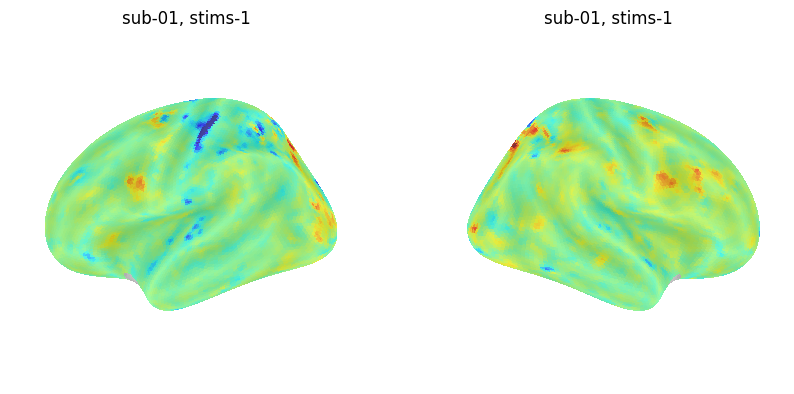

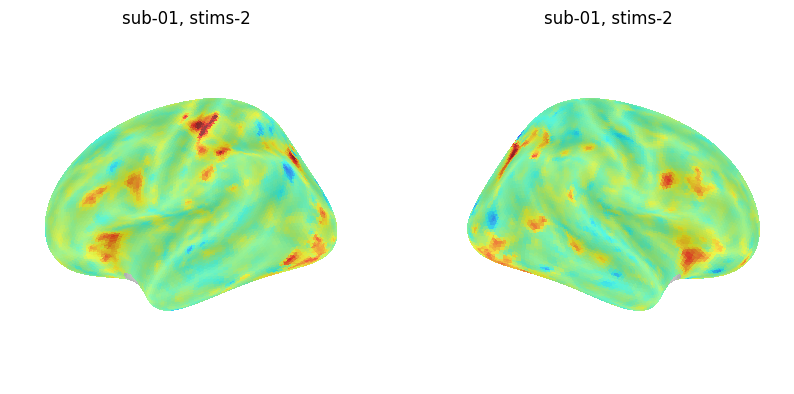

In [ ]:
for stim_n in [1, 2]:
    fig, axes = plt.subplots(1, 2, figsize=(10, 5), subplot_kw={'projection': '3d'})

    for i, hemi in enumerate(['L', 'R']):
        ims = nib.load(op.join(base_dir, f'sub-{sub}_ses-{session}_task-magjudge_space-{space}_desc-stims{stim_n}_pe_hemi-{hemi}.gii'))
        betas = np.array([ims.darrays[i].data for i in range(len(ims.darrays))])
        map = betas.mean(axis=0)

        side_view = 'medial' if hemi == 'R' else 'lateral'
        surf_mesh = fsaverage.infl_right if hemi == 'R' else fsaverage.infl_left
        bg_map = fsaverage.sulc_right if hemi == 'R' else fsaverage.sulc_left
        nplt.plot_surf(surf_mesh= surf_mesh, surf_map= map, # infl_right # pial_right
                    view= side_view,cmap=cmap, colorbar=False,  # sub-{sub}, title=f’grad {i+1}‘,
                    vmax=1,vmin=-1, title=f'sub-{sub}, stims-{stim_n}',
                    bg_map=bg_map, bg_on_data=True,darkness=0.7,axes=axes[i]) #

## Old Debug code with DM problems

<Axes: >

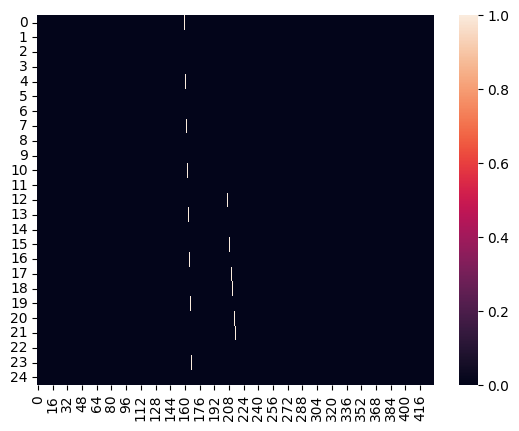

In [84]:
import seaborn as sns
run = 2
start = 50
stop=75
sns.heatmap(X_mig[run][start:stop,:])

In [ ]:
np.where(X_mig[run][61])

(array([205, 210, 213]),)

In [35]:
X_mig[run][61].sum()

3.0

In [50]:
np.where(dm.sum(axis=1)>1)

(array([  6, 191, 439, 573, 758, 964]),)

In [51]:
dm.iloc[[  6, 191, 439, 573, 758, 964]]

,,trial_001_n1,trial_001_n2,trial_002_n1,trial_002_n2,trial_003_n1,trial_003_n2,trial_004_n1,trial_004_n2,trial_005_n1,trial_005_n2,...,trial_212_n1,trial_212_n2,trial_213_n1,trial_213_n2,trial_214_n1,trial_214_n2,trial_215_n1,trial_215_n2,trial_216_n1,trial_216_n2
run,,,,,,,,,,,,,,,,,,,,,,
1,14.95,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,5.75,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,141.45,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,14.95,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,5.75,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,44.85,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [81]:
frametimes

array([  1.15,   3.45,   5.75,   8.05,  10.35,  12.65,  14.95,  17.25,
        19.55,  21.85,  24.15,  26.45,  28.75,  31.05,  33.35,  35.65,
        37.95,  40.25,  42.55,  44.85,  47.15,  49.45,  51.75,  54.05,
        56.35,  58.65,  60.95,  63.25,  65.55,  67.85,  70.15,  72.45,
        74.75,  77.05,  79.35,  81.65,  83.95,  86.25,  88.55,  90.85,
        93.15,  95.45,  97.75, 100.05, 102.35, 104.65, 106.95, 109.25,
       111.55, 113.85, 116.15, 118.45, 120.75, 123.05, 125.35, 127.65,
       129.95, 132.25, 134.55, 136.85, 139.15, 141.45, 143.75, 146.05,
       148.35, 150.65, 152.95, 155.25, 157.55, 159.85, 162.15, 164.45,
       166.75, 169.05, 171.35, 173.65, 175.95, 178.25, 180.55, 182.85,
       185.15, 187.45, 189.75, 192.05, 194.35, 196.65, 198.95, 201.25,
       203.55, 205.85, 208.15, 210.45, 212.75, 215.05, 217.35, 219.65,
       221.95, 224.25, 226.55, 228.85, 231.15, 233.45, 235.75, 238.05,
       240.35, 242.65, 244.95, 247.25, 249.55, 251.85, 254.15, 256.45,
      

In [96]:
run = 1
dm_singlerun = make_first_level_design_matrix(frametimes, 
                                        onsets.loc[run].sort_values('onset'), 
                                        hrf_model='fir', oversampling=100.,
                                        drift_order=0,
                                        drift_model=None).drop('constant', axis=1)
dm_singlerun /= dm_singlerun.max()
dm_singlerun[dm_singlerun < 1.0] = 0.0

In [97]:
dm_singlerun

,trial_001_n1_delay_0,trial_001_n2_delay_0,trial_002_n1_delay_0,trial_002_n2_delay_0,trial_003_n1_delay_0,trial_003_n2_delay_0,trial_004_n1_delay_0,trial_004_n2_delay_0,trial_005_n1_delay_0,trial_005_n2_delay_0,...,trial_032_n1_delay_0,trial_032_n2_delay_0,trial_033_n1_delay_0,trial_033_n2_delay_0,trial_034_n1_delay_0,trial_034_n2_delay_0,trial_035_n1_delay_0,trial_035_n2_delay_0,trial_036_n1_delay_0,trial_036_n2_delay_0
1.15,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3.45,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5.75,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8.05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10.35,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
424.35,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
426.65,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
428.95,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
431.25,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [105]:
TR = np.diff(frametimes).mean()

onsets_aligned = onsets.copy()
onsets_aligned['onset'] = np.clip(
    np.round(onsets['onset'] / TR) * TR,
    frametimes.min(),
    frametimes.max()
)

dm_singlerun = make_first_level_design_matrix(
    frametimes,
    onsets_aligned.loc[run].sort_values('onset'),
    hrf_model='fir',
    drift_order=0,
    drift_model=None
).drop('constant', axis=1)

dm_singlerun /= dm_singlerun.max()
dm_singlerun[dm_singlerun < 1.0] = 0.0


In [112]:
dm_singlerun.sum(axis=0).mean()

1.0

In [113]:
np.unique(dm_singlerun.sum(axis=1))

array([ 0.,  1., 12.])

In [ ]:
dm_singlerun.iloc[6]

trial_001_n1_delay_0    0.0
trial_001_n2_delay_0    0.0
trial_002_n1_delay_0    0.0
trial_002_n2_delay_0    0.0
trial_003_n1_delay_0    0.0
                       ... 
trial_034_n2_delay_0    0.0
trial_035_n1_delay_0    0.0
trial_035_n2_delay_0    0.0
trial_036_n1_delay_0    0.0
trial_036_n2_delay_0    0.0
Name: 14.95, Length: 72, dtype: float64

In [101]:
dm_singlerun['trial_034_n2_delay_0'].sum()

1.0

In [99]:
onsets.loc[run].sort_values('onset')

,onset,duration,trial_type
run,,,
1,2.3,0.6,trial_001_n1
1,11.5,0.6,trial_001_n2
1,18.4,0.6,trial_002_n1
1,27.6,0.6,trial_002_n2
1,32.2,0.6,trial_003_n1
...,...,...,...
1,489.9,0.6,trial_034_n2
1,494.5,0.6,trial_035_n1
1,501.4,0.6,trial_035_n2


In [75]:
np.where(dm_singlerun.sum(axis=1)>1)

(array([6]),)

In [58]:
dm.columns[dm.iloc[6] == 1.0]

Index(['trial_031_n2', 'trial_032_n2', 'trial_034_n2', 'trial_035_n2'], dtype='object')

In [80]:
onsets.loc[1].sort_values('onset').query('onset >= 14.0 and onset <= 15.5')


,onset,duration,trial_type
run,,,


In [67]:
onsets.loc[1].sort_values('onset')

,onset,duration,trial_type
run,,,
1,2.3,0.6,trial_001_n1
1,11.5,0.6,trial_001_n2
1,18.4,0.6,trial_002_n1
1,27.6,0.6,trial_002_n2
1,32.2,0.6,trial_003_n1
...,...,...,...
1,489.9,0.6,trial_034_n2
1,494.5,0.6,trial_035_n1
1,501.4,0.6,trial_035_n2


In [68]:
dm

trial_001_n1  trial_001_n2  trial_002_n1  trial_002_n2  \
run                                                                  
1   1.15             1.0           0.0           0.0           0.0   
    3.45             0.0           0.0           0.0           0.0   
    5.75             0.0           0.0           0.0           0.0   
    8.05             0.0           0.0           0.0           0.0   
    10.35            0.0           1.0           0.0           0.0   
...                  ...           ...           ...           ...   
6   424.35           0.0           0.0           0.0           0.0   
    426.65           0.0           0.0           0.0           0.0   
    428.95           0.0           0.0           0.0           0.0   
    431.25           0.0           0.0           0.0           0.0   
    433.55           0.0           0.0           0.0           0.0   

            trial_003_n1  trial_003_n2  trial_004_n1  trial_004_n2  \
run                                                                  
1   1.15             0.0           0.0           0.0           0.0   
    3.45             0.0           0.0           0.0           0.0   
    5.75             0.0           0.0           0.0           0.0   
    8.05             0.0           0.0           0.0           0.0   
    10.35            0.0           0.0           0.0           0.0   
...                  ...           ...           ...           ...   
6   424.35           0.0           0.0           0.0           0.0   
    426.65           0.0           0.0           0.0           0.0   
    428.95           0.0           0.0           0.0           0.0   
    431.25           0.0           0.0           0.0           0.0   
    433.55           0.0           0.0           0.0           0.0   

            trial_005_n1  trial_005_n2  ...  trial_212_n1  trial_212_n2  \
run                                     ...                               
1   1.15             0.0           0.0  ...           0.0           0.0   
    3.45             0.0           0.0  ...           0.0           0.0   
    5.75             0.0           0.0  ...           0.0           0.0   
    8.05             0.0           0.0  ...           0.0           0.0   
    10.35            0.0           0.0  ...           0.0           0.0   
...                  ...           ...  ...           ...           ...   
6   424.35           0.0           0.0  ...           0.0           0.0   
    426.65           0.0           0.0  ...           0.0           0.0   
    428.95           0.0           0.0  ...           0.0           0.0   
    431.25           0.0           0.0  ...           0.0           0.0   
    433.55           0.0           0.0  ...           0.0           0.0   

            trial_213_n1  trial_213_n2  trial_214_n1  trial_214_n2  \
run                                                                  
1   1.15             0.0           0.0           0.0           0.0   
    3.45             0.0           0.0           0.0           0.0   
    5.75             0.0           0.0           0.0           0.0   
    8.05             0.0           0.0           0.0           0.0   
    10.35            0.0           0.0           0.0           0.0   
...                  ...           ...           ...           ...   
6   424.35           0.0           0.0           0.0           0.0   
    426.65           0.0           0.0           0.0           0.0   
    428.95           0.0           0.0           0.0           0.0   
    431.25           0.0           0.0           0.0           0.0   
    433.55           0.0           0.0           0.0           0.0   

            trial_215_n1  trial_215_n2  trial_216_n1  trial_216_n2  
run                                                                 
1   1.15             0.0           0.0           0.0           0.0  
    3.45             0.0           0.0           0.0           0.0  
    5.75             0.0   

<Axes: >

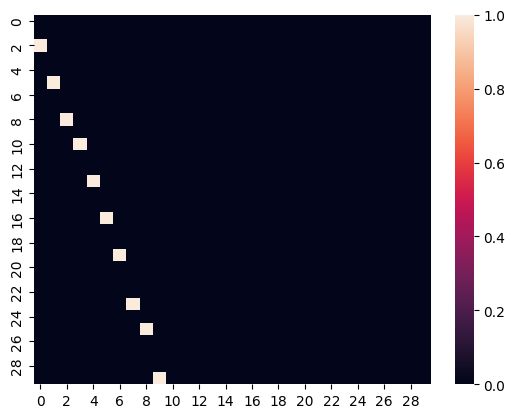

In [72]:
sns.heatmap(X_dys[0][:30,:30])

In [58]:
for run in runs:
    print(np.shape(X_mig[run-1]))
    print(np.shape(im_data[run-1]))
    print(np.unique(X_mig[run-1]))

# runs, volumes, trials*2 (= N_events)

(189, 432)
(20484, 189)
[0. 1.]
(189, 432)
(20484, 189)
[0. 1.]
(189, 432)
(20484, 189)
[0. 1.]
(189, 432)
(20484, 189)
[0. 1.]
(189, 432)
(20484, 189)
[0. 1.]
(189, 432)
(20484, 189)
[0. 1.]


In [59]:
type(X_mig)  # should be list


list

In [38]:
print(np.shape(X_mig))
print(np.shape(im_data))


(6, 189, 432)
(6, 20484, 189)


In [61]:
opt = dict()
opt['wantlibrary'] = 1 # set important fields for completeness (but these would be enabled by default)
opt['wantglmdenoise'] = 1
opt['wantfracridge'] = 1
opt['wantfileoutputs'] = [0, 0, 0, 1] # keep the relevant outputs in memory and also save them to the disk


glmsingle_obj = GLM_single(opt)
tmp_figuredir = op.join(base_dir, 'GLMestimatesingletrialfigures') # would be written to cwd otherwise and could crash when multiple nodes use it a the same time 
results_glmsingle = glmsingle_obj.fit(
    X_mig,
    im_data,
    0.6,
    tr,
    outputdir=base_dir,
    figuredir = tmp_figuredir)

*** FITTING TYPE-A MODEL (ONOFF) ***



AssertionError: 
Arrays are not equal
<design> must consist of 0s and 1s
(shapes (3,), (2,) mismatch)
 x: array([0., 1., 4.])
 y: array([0, 1])

In [24]:
bids_folder

'/mnt_03/ds-dnumrisk'

In [25]:
key = f'glm_stim.denoise.both'
base_dir = op.join(derivatives, key, f'sub-{subject}', f'ses-{session}', 'func')
os.makedirs(base_dir, exist_ok=True)

In [26]:
betas = results_glmsingle['typed']['betasmd']
betas = image.new_img_like(images[0], betas)

#GLM_single stil gives a single image for each event (even if they are put in as one regressor), chronological order
# n1s
betas_n1 = image.index_img(betas, slice(0, None, 2) ) # slice(0, None, 2) where to start, where to end, step size
betas_n1.to_filename(op.join(base_dir, f'sub-{subject}_ses-{session}_task-magjudge_space-{space}_desc-stims1_pe.nii.gz'))

# n2s
betas_n2 = image.index_img(betas, slice(1, None, 2) ) # slice(0, None, 2) where to start, where to end, step size
betas_n2.to_filename(op.join(base_dir, f'sub-{subject}_ses-{session}_task-magjudge_space-{space}_desc-stims2_pe.nii.gz'))


## Renaming/ changing files

In [ ]:
bids_folder = f'/mnt_AdaBD_largefiles/Data/SMILE_DATA/DNumRisk/ds-numrisk'
task = 'magjudge'
space = 'fsaverage5'

for sub in range(2,65):
    subject = f'{int(sub):02d}'
    base = op.join(bids_folder, 'derivatives', 'fmriprep',f'sub-{subject}', f'ses-{session}', 'func')

    for run in runs:
        for hemi in ['L', 'R']:
            source_name =  op.join(base, f'sub-{subject}_ses-{session}_task-{task}_run-{run}_space-{space}_hemi-{hemi}.func.gii')
            target_name =  op.join(base, f'sub-{subject}_ses-{session}_task-{task}_run-{run}_space-{space}_hemi-{hemi}_bold.func.gii')
            os.rename(source_name, target_name)


In [35]:
sub=66

subject = f'{int(sub):02d}'
base = op.join(bids_folder, 'derivatives', 'fmriprep',f'sub-{subject}', f'ses-{session}', 'func')

for run in runs:
    for hemi in ['L', 'R']:
        source_name =  op.join(base, f'sub-{subject}_ses-{session}_task-{task}_run-{run}_space-{space}_hemi-{hemi}.func.gii')
        target_name =  op.join(base, f'sub-{subject}_ses-{session}_task-{task}_run-{run}_space-{space}_hemi-{hemi}_bold.func.gii')
        os.rename(source_name, target_name)

FileNotFoundError: [Errno 2] No such file or directory: '/mnt_AdaBD_largefiles/Data/SMILE_DATA/DNumRisk/ds-numrisk/derivatives/fmriprep/sub-66/ses-1/func/sub-66_ses-1_task-magjudge_run-1_space-fsaverage5_hemi-L.func.gii' -> '/mnt_AdaBD_largefiles/Data/SMILE_DATA/DNumRisk/ds-numrisk/derivatives/fmriprep/sub-66/ses-1/func/sub-66_ses-1_task-magjudge_run-1_space-fsaverage5_hemi-L_bold.func.gii'

In [ ]:
# renumber trials so that they go from 1-180 instead of 1-36 in each run
home_dir = '/mnt_AdaBD_largefiles/Data/SMILE_Data/DNumRisk/ds-numrisk/'
sub = f'{int(subject):02d}'
default_trial_numbers = list(range(1, 37))

import itertools
for run in runs:
    print(run)
    fn = op.join(home_dir, f'sub-{sub}', 'ses-1', 'func', f'sub-{sub}_ses-1_task-magjudge_run-{run}_events.tsv')
    print(fn)
    event_df = pd.read_csv(fn, sep="\t")
    for row in event_df.iterrows():
        row['trial_nr'] = row['trial_nr'] + (run - 1) * 36
    #event_file['trial_nr'] = [trial_nr + (run - 1) * 36 for trial_nr in default_trial_numbers]
    event_df.to_csv(fn, sep="\t", index=False)

# messed up run-2 for sub-10 !!!
    

In [ ]:
session = 1
runs = range(1, 7)
space = 'T1w' #'fsaverage5'

# get fMRI data
images = [op.join(bids_folder, 'derivatives', 'fmriprep', f'sub-{subject}',
        f'ses-{session}', 'func', f'sub-{subject}_ses-{session}_task-magjudge_run-{run}_space-{space}_desc-preproc_bold.nii.gz') 
        for run in runs]
data = [image.load_img(im).get_fdata() for im in images]
print(np.shape(data))


In [ ]:
def get_fmri_events_bothStim(sub, session, runs, bids_folder):
    behavior = []
    for run in runs:
        behavior.append(pd.read_table(op.join(
            bids_folder, f'sub-{sub.subject}/ses-{session}/func/sub-{sub.subject}_ses-{session}_task-magjudge_run-{run}_events.tsv')))

    behavior = pd.concat(behavior, keys=runs, names=['run'])
    behavior = behavior.reset_index().set_index(
        ['run', 'trial_type'])

    behavior = behavior[behavior['trial_nr'] != 0]

    stimulus1 = behavior.xs('stimulus 1', 0, 'trial_type', drop_level=False).reset_index('trial_type')[['onset', 'trial_nr', 'trial_type', 'n1']]
    stimulus1['duration'] = 0.6
    stimulus1['trial_type'] = stimulus1.trial_nr.map(lambda trial: f'trial_{trial:03d}_n1')

    stimulus2 = behavior.xs('stimulus 2', 0, 'trial_type', drop_level=False).reset_index('trial_type')[['onset', 'trial_nr', 'trial_type', 'n2']]
    stimulus2['duration'] = 0.6
    stimulus2['trial_type'] = stimulus2.trial_nr.map(lambda trial: f'trial_{trial:03d}_n2')

    events = pd.concat((stimulus1, stimulus2)).sort_index()
    events = events[['onset', 'duration', 'trial_type']]  
    
    return events 

In [ ]:
import nibabel as nb
fn = '/mnt_04/ds-numrisk/sub-1/func/sub-1_task-numrisk_acq-3_run-1_bold.nii.gz'
img = nb.load(fn)
TR = img.header.get_zooms()[3]  # or equivalently: img.header['pixdim'][4]
print(f"TR = {TR} seconds")